In [54]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import joblib
import time

In [55]:
start_time = time.time()
real_df = pd.read_csv(
    '../datasets/online-retail-ii-cleaned.csv.zstd',
    compression='zstd',
    sep=';'
)

df = real_df.copy()

In [56]:
print(df.info())

display(df.head())

print("Missing Values:")
display(df.isna().sum())

print("Duplicated Rows:", df.duplicated().sum())

display(df[df.duplicated()])

<class 'pandas.DataFrame'>
RangeIndex: 1033036 entries, 0 to 1033035
Data columns (total 23 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   InvoiceID          1033036 non-null  str    
 1   StockCode          1033036 non-null  str    
 2   Description        1033036 non-null  str    
 3   Quantity           1033036 non-null  int64  
 4   InvoiceDate        1033036 non-null  str    
 5   Price              1033036 non-null  float64
 6   CustomerID         1033036 non-null  int64  
 7   Country            1033036 non-null  str    
 8   IsGuest            1033036 non-null  bool   
 9   Hour               1033036 non-null  int64  
 10  Year               1033036 non-null  int64  
 11  Month              1033036 non-null  int64  
 12  Day                1033036 non-null  int64  
 13  Week               1033036 non-null  int64  
 14  DayName            1033036 non-null  str    
 15  MonthName          1033036 non-null  str   

,InvoiceID,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,IsGuest,Hour,...,Week,DayName,MonthName,IsNegQty,IsNegPrice,IsCanceled,IsAdjusted,TotalPrice,IsQuantityOutlier,IsPriceOutlier
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01,6.95,13085,United Kingdom,False,7,...,49,Tuesday,December,False,False,False,False,83.4,False,False
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01,6.75,13085,United Kingdom,False,7,...,49,Tuesday,December,False,False,False,False,81.0,False,False
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01,6.75,13085,United Kingdom,False,7,...,49,Tuesday,December,False,False,False,False,81.0,False,False
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01,2.10,13085,United Kingdom,False,7,...,49,Tuesday,December,False,False,False,False,100.8,True,False
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01,1.25,13085,United Kingdom,False,7,...,49,Tuesday,December,False,False,False,False,30.0,True,False


Missing Values:


InvoiceID            0
StockCode            0
Description          0
Quantity             0
InvoiceDate          0
Price                0
CustomerID           0
Country              0
IsGuest              0
Hour                 0
Year                 0
Month                0
Day                  0
Week                 0
DayName              0
MonthName            0
IsNegQty             0
IsNegPrice           0
IsCanceled           0
IsAdjusted           0
TotalPrice           0
IsQuantityOutlier    0
IsPriceOutlier       0
dtype: int64

Duplicated Rows: 2


,InvoiceID,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,IsGuest,Hour,...,Week,DayName,MonthName,IsNegQty,IsNegPrice,IsCanceled,IsAdjusted,TotalPrice,IsQuantityOutlier,IsPriceOutlier
41180,492807,21813,GARLAND WITH STARS AND BELLS,6,2009-12-20,4.95,17211,United Kingdom,False,12,...,51,Sunday,December,False,False,False,False,29.7,False,False
839988,567183,22659,LUNCH BOX I LOVE LONDON,2,2011-09-18,1.95,14769,United Kingdom,False,15,...,37,Sunday,September,False,False,False,False,3.9,False,False


In [57]:
df = df[~df.duplicated()]

print("Remaining duplicates:", df.duplicated().sum())

Remaining duplicates: 0


In [58]:
df_clean = df[
    (~df['IsNegQty']) &
    (~df['IsNegPrice']) &
    (~df['IsQuantityOutlier']) &
    (~df['IsPriceOutlier']) &
    (~df['IsGuest']) &
    (~df['IsCanceled'])  # hanya transaksi sukses
].copy()

In [59]:
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

In [60]:
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

In [61]:
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'InvoiceID': 'nunique',                                   # Frequency
    'TotalPrice': 'sum'                                       # Monetary
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

display(rfm.head())

,CustomerID,Recency,Frequency,Monetary
0,12346,530,11,372.86
1,12347,3,8,3309.37
2,12348,249,2,118.20
3,12349,19,3,2685.44
4,12350,311,1,274.00


In [62]:
rfm_log = rfm[['Recency', 'Frequency', 'Monetary']].apply(np.log1p)

display(rfm_log.describe())

,Recency,Frequency,Monetary
count,5654.000000,5654.000000,5654.000000
mean,4.482460,1.516442,6.345335
std,1.523343,0.784630,1.346892
min,0.693147,0.693147,0.000000
25%,3.332205,0.693147,5.419583
50%,4.584967,1.386294,6.333581
75%,5.942799,1.945910,7.255199
max,6.606650,5.905362,11.976064


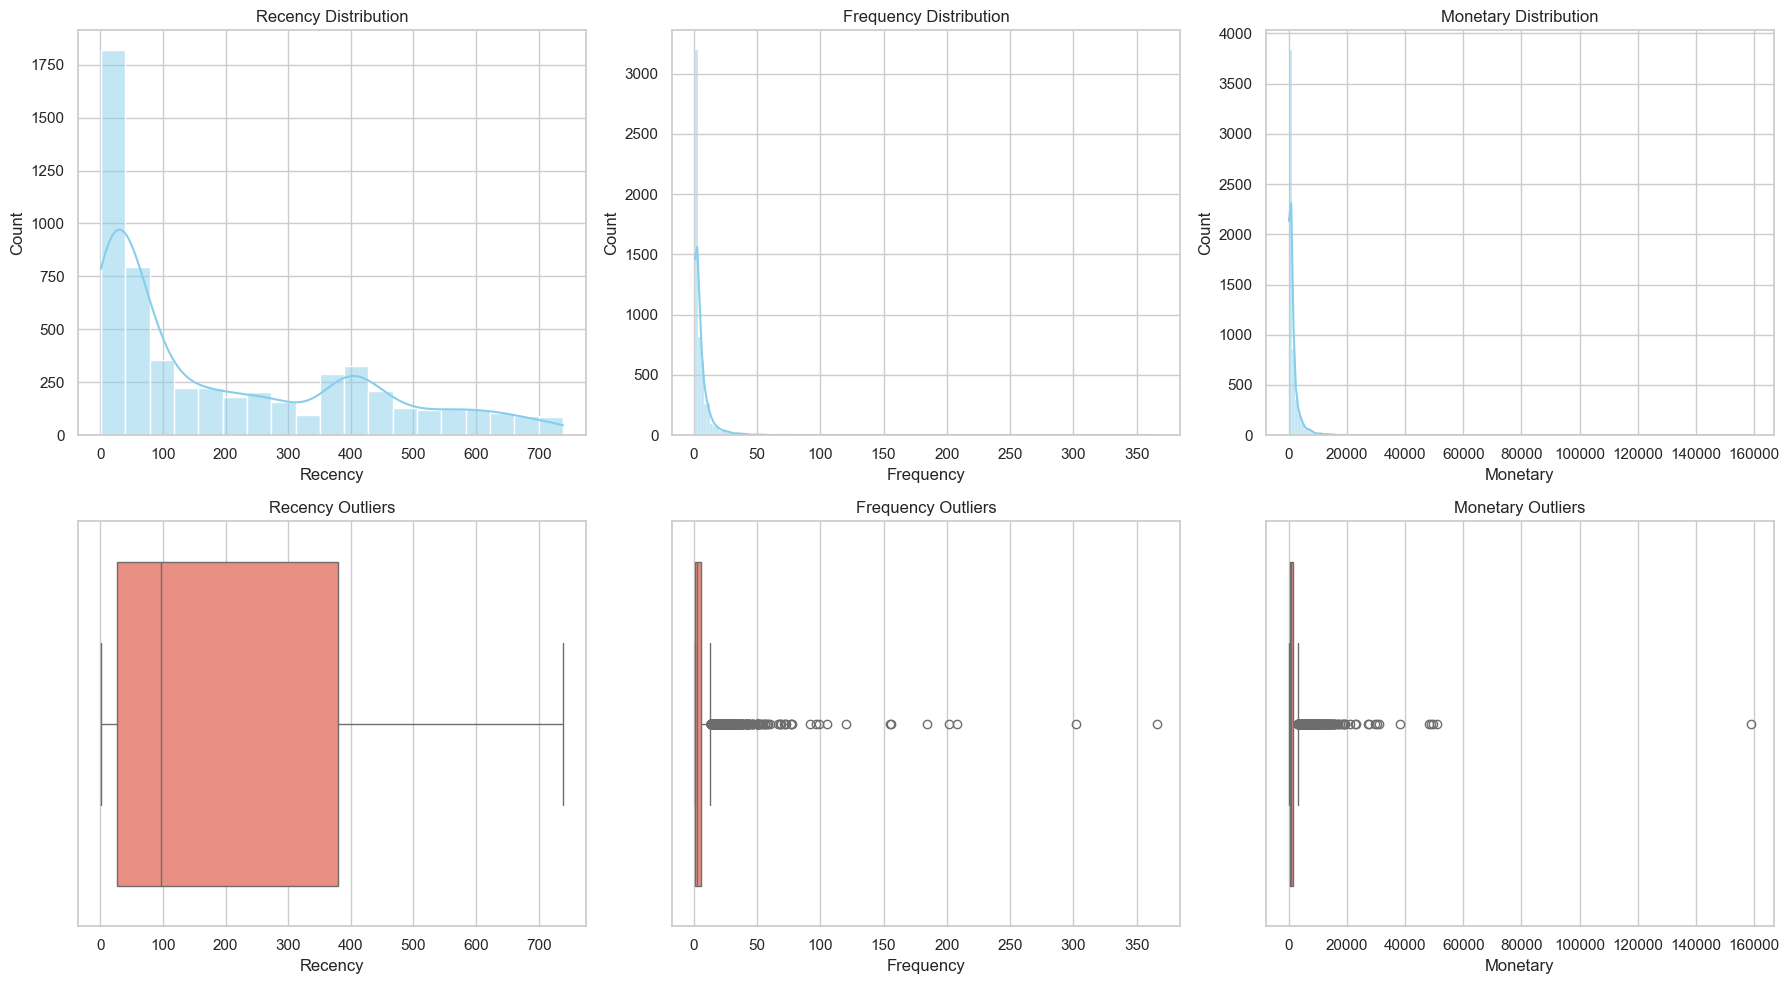

In [63]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(2, 3, figsize=(18, 10))
features = ['Recency', 'Frequency', 'Monetary']

for i, col in enumerate(features):

    sns.histplot(rfm[col], kde=True, ax=ax[0, i], color='skyblue')
    ax[0, i].set_title(f'{col} Distribution')

    sns.boxplot(x=rfm[col], ax=ax[1, i], color='salmon')
    ax[1, i].set_title(f'{col} Outliers')

plt.tight_layout()
plt.show()

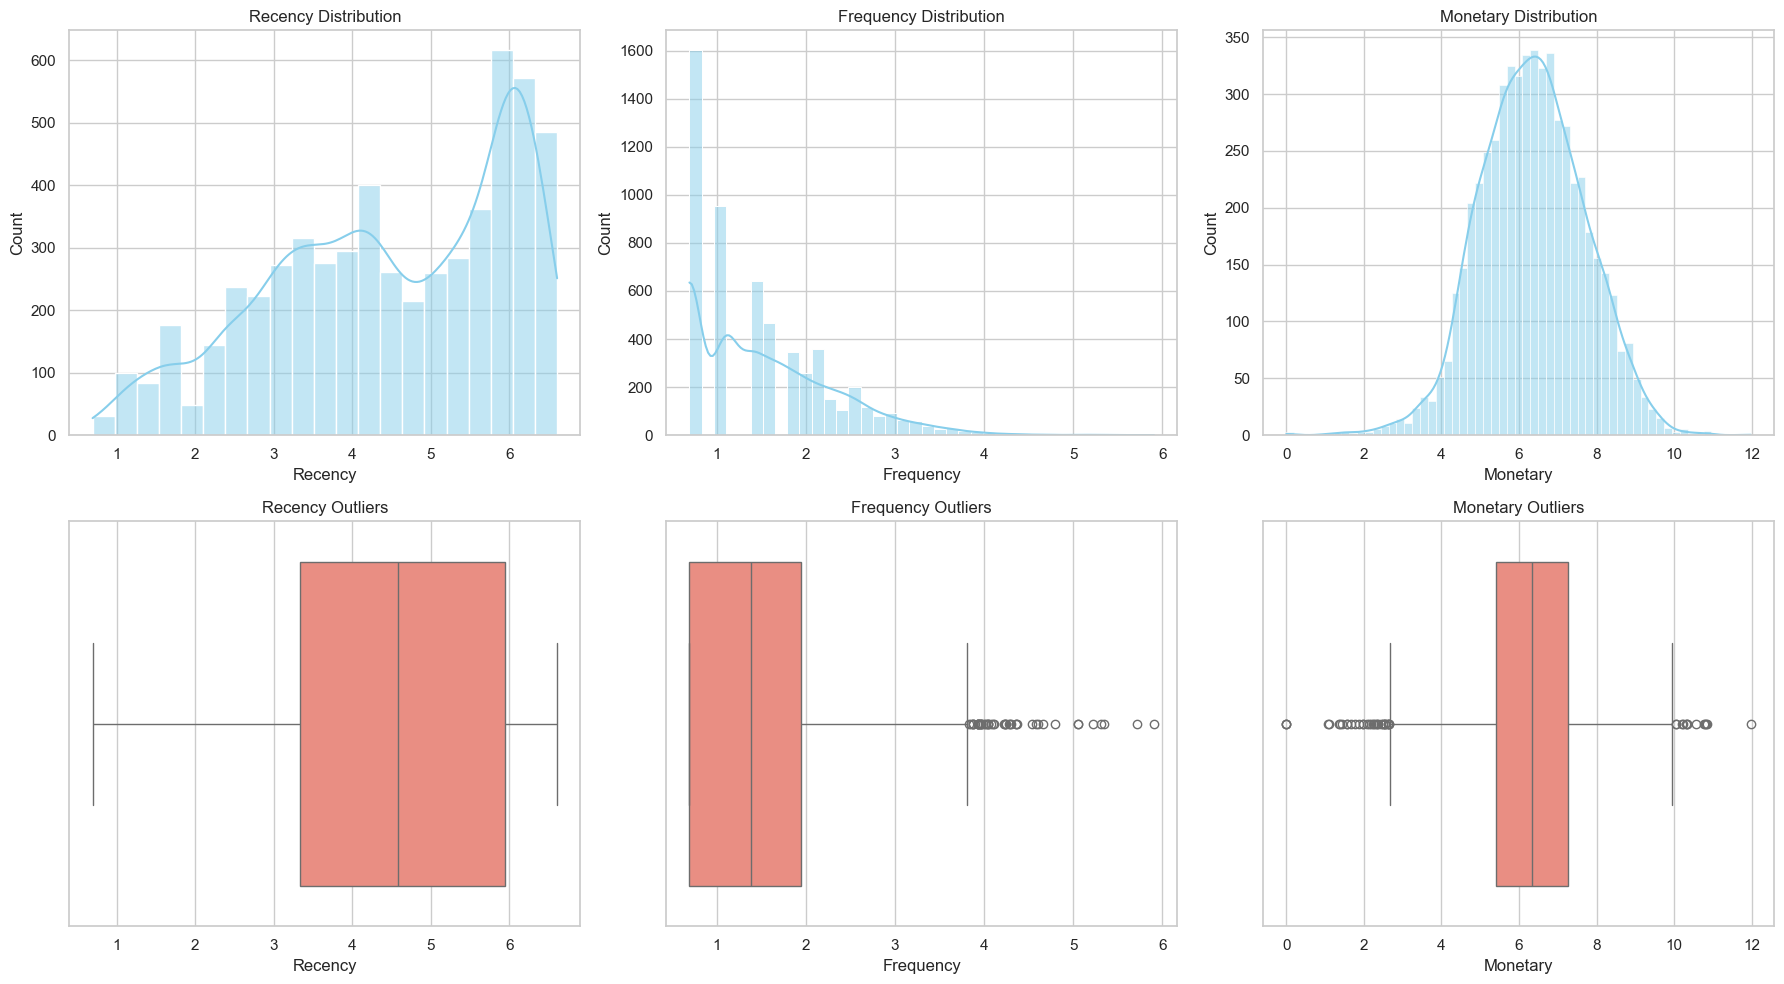

In [64]:
fig, ax = plt.subplots(2, 3, figsize=(18, 10))
features = ['Recency', 'Frequency', 'Monetary']

for i, col in enumerate(features):

    sns.histplot(rfm_log[col], kde=True, ax=ax[0, i], color='skyblue')
    ax[0, i].set_title(f'{col} Distribution')

    sns.boxplot(x=rfm_log[col], ax=ax[1, i], color='salmon')
    ax[1, i].set_title(f'{col} Outliers')

plt.tight_layout()
plt.show()

In [65]:
scaler = RobustScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

df_scaled = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary']
)

display(df_scaled.head())

,Recency,Frequency,Monetary
0,0.647283,0.876951,-0.223195
1,-1.225266,0.647313,0.964926
2,0.358728,-0.229638,-0.845917
3,-0.608764,0.000000,0.851153
4,0.443591,-0.553295,-0.390501


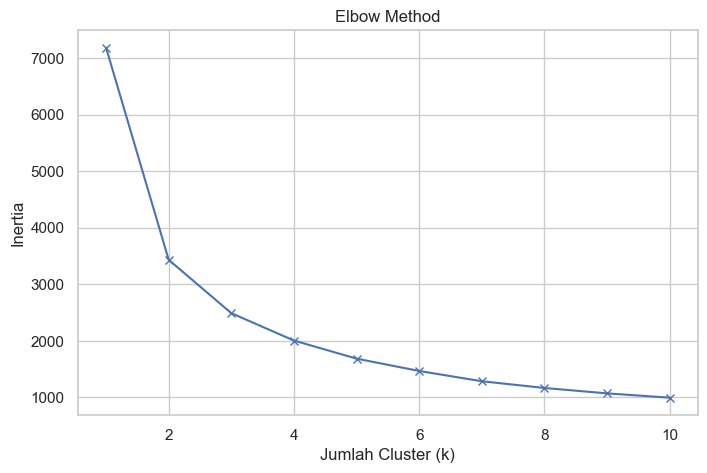

In [66]:
inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [67]:
for k in range(2, 8):

    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_scaled)

    score = silhouette_score(df_scaled, labels)

    print(f"k={k}, silhouette={score:.3f}")

k=2, silhouette=0.439
k=3, silhouette=0.352
k=4, silhouette=0.357
k=5, silhouette=0.324
k=6, silhouette=0.298
k=7, silhouette=0.305


In [68]:
k_optimal = 4

kmeans = KMeans(
    n_clusters=k_optimal,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(df_scaled)

display(rfm.head())

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346,530,11,372.86,3
1,12347,3,8,3309.37,1
2,12348,249,2,118.20,0
3,12349,19,3,2685.44,2
4,12350,311,1,274.00,0


In [69]:
cluster_analysis = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(2)

display(cluster_analysis)

Recency Frequency Monetary      
           mean      mean     mean count
Cluster                                 
0        381.91      1.34   188.38  1882
1         33.13     17.32  4531.31  1181
2         28.42      3.12   590.10  1165
3        246.46      4.41  1038.36  1426

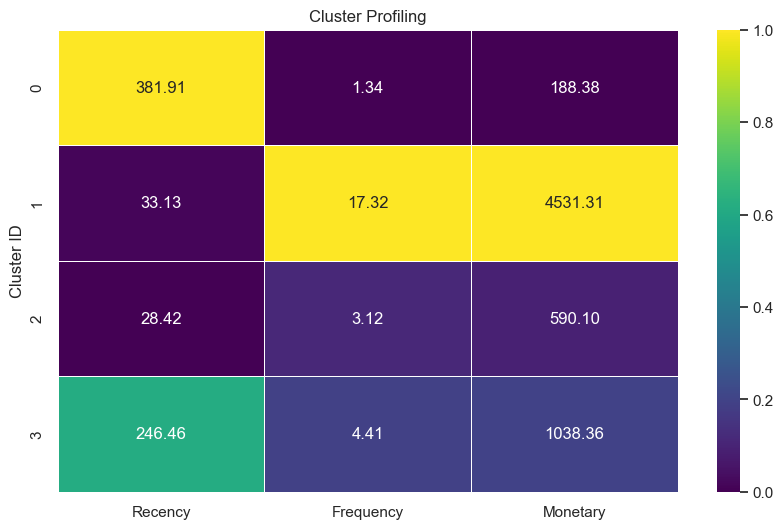

<Figure size 640x480 with 0 Axes>

In [70]:
heatmap_data = cluster_analysis.drop(columns=('Monetary', 'count'))

heatmap_data.columns = ['Recency', 'Frequency', 'Monetary']

heatmap_norm = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())

plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_norm,
    annot=heatmap_data,
    fmt='.2f',
    cmap='viridis',
    linewidths=.5
)

plt.title('Cluster Profiling')
plt.ylabel('Cluster ID')

plt.show()

plt.savefig(
    "../outputs/rfm_cluster_heatmap.png",
    dpi=300,
    bbox_inches='tight'
)

In [71]:
fig = px.scatter_3d(
    rfm,
    x='Recency',
    y='Frequency',
    z='Monetary',
    color='Cluster',
    opacity=0.7,
    title='Customer Segmentation (RFM)'
)

fig.show()

In [72]:
rfm.to_csv(
    '../outputs/rfm_customer_segmentation.csv',
    index=False
)

print("File exported: rfm_customer_segmentation.csv")

File exported: rfm_customer_segmentation.csv


In [73]:
cluster_analysis.to_csv(
    '../outputs/rfm_cluster_profile.csv'
)

print("File exported: rfm_cluster_profile.csv")

File exported: rfm_cluster_profile.csv


In [74]:
joblib.dump(kmeans, "../outputs/kmeans_rfm_model.pkl")

['../outputs/kmeans_rfm_model.pkl']

In [75]:
joblib.dump(
    scaler,
    "../outputs/rfm_scaler.pkl"
)

print("Scaler saved")

Scaler saved


In [76]:
kmeans_loaded = joblib.load("../outputs/kmeans_rfm_model.pkl")
scaler_loaded = joblib.load("../outputs/rfm_scaler.pkl")

In [77]:
import numpy as np
import pandas as pd

new_customer = pd.DataFrame({
    "Recency":[10],
    "Frequency":[5],
    "Monetary":[120]
})

In [78]:
new_customer_log = np.log1p(new_customer)

new_customer_scaled = scaler_loaded.transform(new_customer_log)

In [79]:
cluster = kmeans_loaded.predict(new_customer_scaled)

print("Customer cluster:", cluster[0])

Customer cluster: 2


In [80]:
end_time = time.time()
total_time = end_time - start_time

print(f"Total runtime: {total_time:.2f} seconds")

Total runtime: 6.24 seconds
